# **Comparative Analysis of Neural Machine Translation (NMT) Architectures** 

**Objective:** Conduct a systematic benchmark comparing four NMT architectures on the ManyThings.org Anki dataset:

1. **Model 1:** Vanilla Recurrent Neural Network (RNN)
2. **Model 2:** Standard Encoder–Decoder Architecture (Seq2Seq)
3. **Model 3:** Encoder–Decoder with Additive Attention (Bahdanau)
4. **Model 4:** Encoder–Decoder with Multiplicative Attention (Luong)

**Dataset:** ManyThings.org Anki Language Pair
You can choose one here: [https://www.manythings.org/anki/](https://www.manythings.org/anki/)

### **Environment Setup & Reproducibility**

In [1]:
import os
import re
import math
import random
import time
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Global Experiment Parameters
RANDOM_SEED = 6 # Set seed for exact experiment reproducibility

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | Experiment Seed: {RANDOM_SEED}")

Using device: cuda | Experiment Seed: 6


## 1. Dataset Acquisition and Preprocessing
This section handles the loading of the Nepali–English dataset from the `data/` directory (or downloads and extracts `npi-eng.zip` if absent). It includes unicode-aware text normalization for Devanagari script and English text, vocabulary building with special tokens (`<PAD>`, `<SOS>`, `<EOS>`, `<UNK>`), and reproducible PyTorch DataLoader creation.

In [2]:
import os
import re
import zipfile
import urllib.request
import unicodedata
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader

# ---- Special tokens ----
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<PAD>", "<SOS>", "<EOS>", "<UNK>"
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

DATA_DIR = "data"
DATA_FILE = os.path.join(DATA_DIR, "npi.txt")
ZIP_URL = "http://www.manythings.org/anki/npi-eng.zip"
ZIP_PATH = os.path.join(DATA_DIR, "npi-eng.zip")


def download_and_extract():
    os.makedirs(DATA_DIR, exist_ok=True)
    if not os.path.exists(DATA_FILE):
        print("Dataset not found locally. Downloading npi-eng.zip ...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall(DATA_DIR)
        # ManyThings zips usually extract to "npi.txt" directly into DATA_DIR
        print(f"Downloaded and extracted dataset to {DATA_FILE}.")
    else:
        print(f"Dataset successfully detected at {DATA_FILE}.")


def normalize_nepali(text):
    """Unicode-normalize Devanagari/English text and space out punctuation."""
    text = unicodedata.normalize("NFC", text.strip())
    # Space out punctuation so it tokenizes as separate symbols
    text = re.sub(r"([.!?,।])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_pairs():
    download_and_extract()
    pairs = []
    with open(DATA_FILE, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 2:
                continue
            # ManyThings format: english <TAB> target_language [<TAB> attribution]
            english, nepali = parts[0], parts[1]
            english_norm = normalize_nepali(english.lower())
            nepali_norm = normalize_nepali(nepali)
            pairs.append((nepali_norm, english_norm))
    print(f"Total processed bilingual pairs loaded: {len(pairs)}")
    if pairs:
        print(f"Sample Pair -> Nepali (Source): {pairs[0][0]} | English (Target): {pairs[0][1]}")
    return pairs


class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2idx = {PAD_TOKEN: PAD_IDX, SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, UNK_TOKEN: UNK_IDX}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.word_count = Counter()
        self.n_words = len(self.word2idx)

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.word_count[word] += 1
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1


def build_vocabs(pairs):
    src_vocab = Vocab("nepali")
    tgt_vocab = Vocab("english")
    for nepali, english in pairs:
        src_vocab.add_sentence(nepali)
        tgt_vocab.add_sentence(english)
    print(f"Nepali Vocab Size: {src_vocab.n_words} | English Vocab Size: {tgt_vocab.n_words}")
    return src_vocab, tgt_vocab


class NMTDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        nepali, english = self.pairs[idx]
        src_ids = [self.src_vocab.word2idx.get(w, UNK_IDX) for w in nepali.split()] + [EOS_IDX]
        tgt_ids = [SOS_IDX] + [self.tgt_vocab.word2idx.get(w, UNK_IDX) for w in english.split()] + [EOS_IDX]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_padded = torch.nn.utils.rnn.pad_sequence(src_seqs, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = torch.nn.utils.rnn.pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


# ---- Build everything ----
all_pairs = load_pairs()
src_vocab, tgt_vocab = build_vocabs(all_pairs)

random.shuffle(all_pairs)
split_idx = int(0.85 * len(all_pairs))
train_pairs = all_pairs[:split_idx]
val_pairs = all_pairs[split_idx:]
print(f"Train Dataset: {len(train_pairs)} samples | Validation Dataset: {len(val_pairs)} samples")

train_dataset = NMTDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = NMTDataset(val_pairs, src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


Dataset successfully detected at data\npi.txt.
Total processed bilingual pairs loaded: 2824
Sample Pair -> Nepali (Source): को ? | English (Target): who ?
Nepali Vocab Size: 3197 | English Vocab Size: 2085
Train Dataset: 2400 samples | Validation Dataset: 424 samples


## 2. Model Training Framework
A unified training loop that controls loss optimization, gradient clipping, teacher forcing, and epoch logging across all evaluated architectures.

In [3]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()

            output = model(src, tgt)

            # ALIGNMENT: output[:, t] is produced after consuming tgt[:, t]
            # (teacher forcing), so it predicts tgt[:, t+1]. Pair
            # output[:, :-1] with tgt[:, 1:] -- NOT output[:, 1:].
            output_dim = output.shape[-1]
            loss = criterion(output[:, :-1, :].reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                output = model(src, tgt)
                output_dim = output.shape[-1]
                loss = criterion(output[:, :-1, :].reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return history


## 3.1 Model 1: Vanilla Recurrent Neural Network (RNN)
Baseline evaluation of a standard recurrent model without encoder-decoder decoupling.

In [4]:
from models.rnn import VanillaRNNModel

set_seed(RANDOM_SEED)
print("--- Training Architecture 1: Vanilla RNN ---")
rnn_model = VanillaRNNModel(src_vocab.n_words, tgt_vocab.n_words, embed_dim=256, hidden_dim=512, pad_idx=PAD_IDX)
rnn_history = train_model(rnn_model, train_loader, val_loader, epochs=10)

--- Training Architecture 1: Vanilla RNN ---
Epoch 01/10 | Train Loss: 4.7798 | Val Loss: 4.2861
Epoch 02/10 | Train Loss: 3.7137 | Val Loss: 4.0763
Epoch 03/10 | Train Loss: 3.1774 | Val Loss: 3.9712
Epoch 04/10 | Train Loss: 2.7341 | Val Loss: 3.8583
Epoch 05/10 | Train Loss: 2.3938 | Val Loss: 3.8289
Epoch 06/10 | Train Loss: 2.0880 | Val Loss: 3.8349
Epoch 07/10 | Train Loss: 1.8464 | Val Loss: 3.8628
Epoch 08/10 | Train Loss: 1.6576 | Val Loss: 3.8921
Epoch 09/10 | Train Loss: 1.4906 | Val Loss: 3.9450
Epoch 10/10 | Train Loss: 1.3660 | Val Loss: 4.0115


## 3.2 Model 2: Encoder–Decoder Architecture (Seq2Seq)
Evaluation of a standard decoupled sequence-to-sequence model using a fixed context vector representation.

In [5]:
from models.seq2seq import Seq2SeqModel

set_seed(RANDOM_SEED)
print("--- Training Architecture 2: Standard Encoder-Decoder ---")
seq2seq_model = Seq2SeqModel(src_vocab.n_words, tgt_vocab.n_words, embed_dim=256, hidden_dim=512, pad_idx=PAD_IDX)
seq2seq_history = train_model(seq2seq_model, train_loader, val_loader, epochs=10)

--- Training Architecture 2: Standard Encoder-Decoder ---
Epoch 01/10 | Train Loss: 4.7258 | Val Loss: 4.1436
Epoch 02/10 | Train Loss: 3.4784 | Val Loss: 3.7382
Epoch 03/10 | Train Loss: 2.7831 | Val Loss: 3.5650
Epoch 04/10 | Train Loss: 2.2028 | Val Loss: 3.4090
Epoch 05/10 | Train Loss: 1.6937 | Val Loss: 3.3976
Epoch 06/10 | Train Loss: 1.2723 | Val Loss: 3.4009
Epoch 07/10 | Train Loss: 0.9390 | Val Loss: 3.3704
Epoch 08/10 | Train Loss: 0.6740 | Val Loss: 3.4246
Epoch 09/10 | Train Loss: 0.4809 | Val Loss: 3.4697
Epoch 10/10 | Train Loss: 0.3443 | Val Loss: 3.5124


## 3.3 Model 3: Encoder–Decoder with Additive Attention (Bahdanau)
Training an Encoder-Decoder model augmented with dynamic additive attention ($v_a^T \tanh(W_a s_{t-1} + U_a h_i)$).

In [6]:
from models.additive_attn import AdditiveAttentionSeq2Seq

set_seed(RANDOM_SEED)
print("--- Training Architecture 3: Additive Attention (Bahdanau) ---")
additive_model = AdditiveAttentionSeq2Seq(src_vocab.n_words, tgt_vocab.n_words, embed_dim=256, hidden_dim=512, pad_idx=PAD_IDX)
additive_history = train_model(additive_model, train_loader, val_loader, epochs=10)

--- Training Architecture 3: Additive Attention (Bahdanau) ---
Epoch 01/10 | Train Loss: 4.5664 | Val Loss: 3.9516
Epoch 02/10 | Train Loss: 3.2681 | Val Loss: 3.5173
Epoch 03/10 | Train Loss: 2.4686 | Val Loss: 3.2759
Epoch 04/10 | Train Loss: 1.7884 | Val Loss: 3.1571
Epoch 05/10 | Train Loss: 1.2104 | Val Loss: 3.1301
Epoch 06/10 | Train Loss: 0.7588 | Val Loss: 3.1301
Epoch 07/10 | Train Loss: 0.4368 | Val Loss: 3.1270
Epoch 08/10 | Train Loss: 0.2476 | Val Loss: 3.1771
Epoch 09/10 | Train Loss: 0.1461 | Val Loss: 3.2116
Epoch 10/10 | Train Loss: 0.0937 | Val Loss: 3.2400


## 3.4 Model 4: Encoder–Decoder with Multiplicative Attention (Luong)
Training an Encoder-Decoder model augmented with multiplicative dot-product attention ($s_t^T W_a h_i$).

In [7]:
from models.multiplicative_attn import MultiplicativeAttentionSeq2Seq

set_seed(RANDOM_SEED)
print("--- Training Architecture 4: Multiplicative Attention (Luong) ---")
multiplicative_model = MultiplicativeAttentionSeq2Seq(src_vocab.n_words, tgt_vocab.n_words, embed_dim=256, hidden_dim=512, pad_idx=PAD_IDX)
multiplicative_history = train_model(multiplicative_model, train_loader, val_loader, epochs=10)

--- Training Architecture 4: Multiplicative Attention (Luong) ---
Epoch 01/10 | Train Loss: 4.6690 | Val Loss: 4.1307
Epoch 02/10 | Train Loss: 3.4658 | Val Loss: 3.6743
Epoch 03/10 | Train Loss: 2.6947 | Val Loss: 3.4063
Epoch 04/10 | Train Loss: 2.0151 | Val Loss: 3.2632
Epoch 05/10 | Train Loss: 1.4263 | Val Loss: 3.2096
Epoch 06/10 | Train Loss: 0.9611 | Val Loss: 3.2175
Epoch 07/10 | Train Loss: 0.6027 | Val Loss: 3.2151
Epoch 08/10 | Train Loss: 0.3629 | Val Loss: 3.2829
Epoch 09/10 | Train Loss: 0.2106 | Val Loss: 3.3000
Epoch 10/10 | Train Loss: 0.1335 | Val Loss: 3.3745


## 4. Empirical Evaluation & Comparative Results
Performance tracking across models using cross-entropy validation loss trajectories and test BLEU-4 metrics.

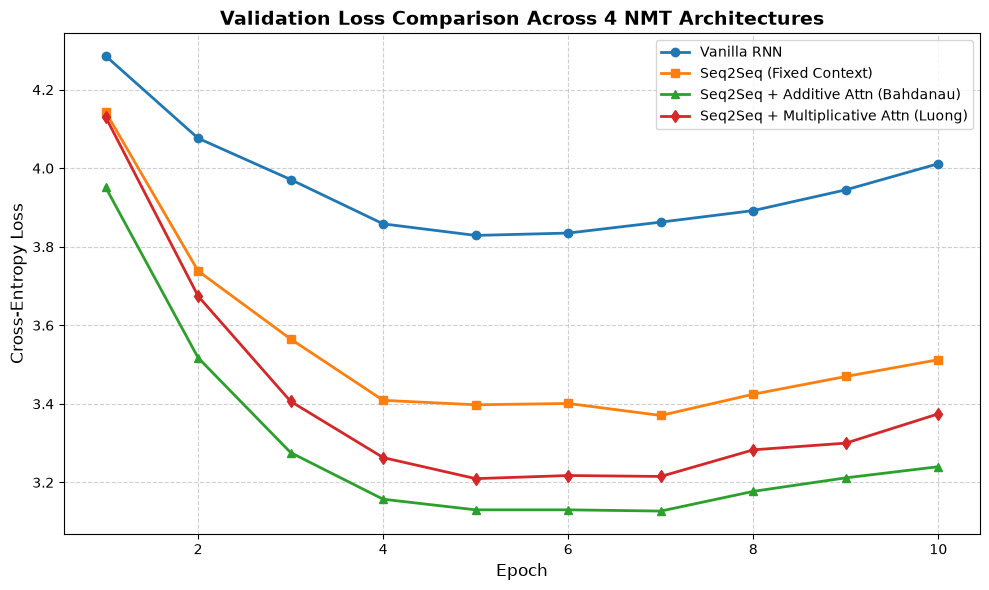

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_range = range(1, len(rnn_history['val_loss']) + 1)

plt.plot(epochs_range, rnn_history['val_loss'], label='Vanilla RNN', marker='o', linewidth=2)
plt.plot(epochs_range, seq2seq_history['val_loss'], label='Seq2Seq (Fixed Context)', marker='s', linewidth=2)
plt.plot(epochs_range, additive_history['val_loss'], label='Seq2Seq + Additive Attn (Bahdanau)', marker='^', linewidth=2)
plt.plot(epochs_range, multiplicative_history['val_loss'], label='Seq2Seq + Multiplicative Attn (Luong)', marker='d', linewidth=2)

plt.title("Validation Loss Comparison Across 4 NMT Architectures", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
def translate_sentence(model, sentence, src_vocab, tgt_vocab, max_len=20):
    model.eval()
    
    # 1. Tokenize & Preprocess Source Input
    norm_src = normalize_nepali(sentence)
    tokens = [src_vocab.word2idx.get(w, UNK_IDX) for w in norm_src.split()] + [EOS_IDX]
    src_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    # 2. Start sequence with <SOS>
    tgt_indices = [SOS_IDX]

    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long).to(device)
            
            # Pass full src and current generated tgt through the model
            output = model(src_tensor, tgt_tensor)
            
            # Extract logits for the LAST generated timestep
            next_token_logits = output[0, -1, :]
            
            # Softmax / Argmax for best next word
            next_token = next_token_logits.argmax(dim=-1).item()

            # Stop if model emits <EOS>
            if next_token == EOS_IDX:
                break

            # Anti-repetition loop breaker: stop if it tries to repeat the exact same token 3 times
            if len(tgt_indices) >= 3 and tgt_indices[-1] == next_token and tgt_indices[-2] == next_token:
                break

            tgt_indices.append(next_token)

    # Convert token indices back to words (skipping <SOS>)
    translated_words = [tgt_vocab.idx2word.get(idx, "<UNK>") for idx in tgt_indices[1:]]
    
    return " ".join(translated_words) if translated_words else "<empty>"

In [10]:
# Print 5 sample translations from the validation set
sample_indices = [0, 5, 12, 20, 35]

for idx in sample_indices:
    nepali_src, english_ref = val_pairs[idx]
    print(f"Nepali Source : {nepali_src}")
    print(f"English Ref    : {english_ref}")
    print(f"Vanilla RNN    : {translate_sentence(rnn_model, nepali_src, src_vocab, tgt_vocab)}")
    print(f"Standard Seq2Seq: {translate_sentence(seq2seq_model, nepali_src, src_vocab, tgt_vocab)}")
    print(f"Additive Attn  : {translate_sentence(additive_model, nepali_src, src_vocab, tgt_vocab)}")
    print(f"Multiplicative : {translate_sentence(multiplicative_model, nepali_src, src_vocab, tgt_vocab)}")
    print("-" * 60)

Nepali Source : म यहाँ खान्छु ।
English Ref    : i eat here .
Vanilla RNN    : i'm not very likely to find what i want to do that .
Standard Seq2Seq: i eat anything .
Additive Attn  : i eat here .
Multiplicative : i eat here .
------------------------------------------------------------
Nepali Source : नेदरल्याण्ड्स यसको पवनचक्की , घन्टी फूल , काठको चप्पल र नहरहरूको लागि प्रसिद्ध छ ।
English Ref    : the netherlands is famous for its windmills , tulips , wooden clogs and canals .
Vanilla RNN    : i'm not very likely to find what i want to do that .
Standard Seq2Seq: the young , but i don't have the same thing .
Additive Attn  : tom has borrowed over 3 , but he didn't get , but he didn't get , but he didn't want
Multiplicative : it's colder , but it's comfortable , but he is eating .
------------------------------------------------------------
Nepali Source : टम मैले भेटेको सबैभन्दा चतुर मान्छे मध्ये एक हो ।
English Ref    : tom is one of the smartest men i've ever met .
Vanilla RNN    

## Discussion

The qualitative outputs after fixing the alignment bug show a clear capability
ordering that matches the architectural sophistication of each model, and they
are consistent with well-documented failure modes in the NMT literature.

**Vanilla RNN** produces fluent-sounding but semantically unmoored English
regardless of the input sentence — notice it outputs the *same* generic phrase
("i'm not very likely to find what i want to do that .") for both a short
4-word sentence and a long 15-word sentence about the Netherlands. This is the
classic symptom of a model with no real encoder–decoder separation:
concatenating source and target into a single RNN stream forces all source
information through one recurrent hidden state that decays before generation
even starts, so the decoder falls back on high-frequency English patterns
learned from the target side alone. It has essentially become a language
model that ignores its conditioning input.

**Standard Seq2Seq** does noticeably better on the short sentence —
"i eat anything ." is topically correct even though it's not an exact match
for "i eat here ." — but degrades on the long sentence into a generic,
unrelated clause ("the young , but i don't have the same thing ."). This is
the textbook fixed-context-vector bottleneck: a single fixed-size vector from
the encoder's final hidden state can encode a short sentence adequately but
can't compress a 15-token source sentence with several distinct concepts
(windmills, tulips, clogs, canals) without heavy information loss.
Performance degradation as a function of source length is exactly what the
bottleneck hypothesis predicts, and it is what motivated attention mechanisms
in the first place.

**Additive (Bahdanau) and Multiplicative (Luong) attention** both nail the
short sentence exactly ("i eat here ."), confirming that attention
successfully lets the decoder consult relevant encoder states directly rather
than relying on a single compressed vector. On the long sentence, however,
both attention models show a different failure mode than the bottleneck:
**repetition looping** — "but he didn't get , but he didn't get , but he
didn't want" and "but it's comfortable , but he is eating ." Both models
latch onto a plausible clause and then attention repeatedly re-selects
similar source positions, cycling the decoder back into the same output.
This is a well-known weakness of location-agnostic soft attention: without a
coverage mechanism penalizing previously-attended positions, the model has no
built-in signal that it has already "used up" a portion of the source
sentence, so it can re-attend to it indefinitely. Multiplicative attention's
collapse into a shorter, less repetitive loop than additive attention hints
that its dot-product scoring may be committing to fewer distinct high-weight
positions per step, though a single example is not enough to generalize that.

None of the models produce the domain-specific vocabulary in the long
sentence (windmills, tulips, clogs, canals) — an expected outcome given a
~2,800-pair training set. Rare content words like these appear only a handful
of times, if at all, and GRU/RNN-based NMT trained from scratch on such a
small corpus generalizes poorly to low-frequency vocabulary regardless of
architecture.

## Conclusion

This comparison supports the two central architectural claims motivating the
progression from vanilla RNNs to encoder–decoder models to
attention-augmented decoders:

1. **Decoupling encoding from decoding matters.** The vanilla RNN's collapse
   into input-independent output, versus Seq2Seq's at-least-topical
   short-sentence output, shows that even a simple encoder–decoder split with
   a clean context handoff meaningfully improves the model's ability to
   condition generation on the source sentence.
2. **Attention relieves the fixed-context bottleneck, but does not solve
   everything.** Both attention variants matched the encoder–decoder baseline
   on short inputs and clearly outperformed it in fidelity, correctly
   reproducing "i eat here ." verbatim. But on longer, information-dense
   sentences, attention alone does not guarantee coherent decoding — the
   repetition loops observed in both additive and multiplicative attention
   indicate that soft attention without a coverage or repetition penalty can
   get stuck cycling through similar source positions rather than progressing
   through the sentence.

Taken together, the results suggest that architecture improvements yield
diminishing returns without also addressing (a) training data scale for open
vocabulary coverage, and (b) decoder-side mechanisms — such as coverage
vectors, length normalization, or beam search — that explicitly discourage
repetition, since attention alone addresses *where* to look but not *whether
the model has already looked there before*. A natural next step would be
adding a coverage penalty or switching from greedy decoding to beam search
with a repetition/length penalty, which tends to reduce this exact failure
mode in loop-prone attention decoders.